# Exemplo de Segmentação de Pele por Cor
Neste notebook vamos realizar a segmentação das tonalidades de pele humana presentes em uma imagem digital a partir de limiarização no espaço cromático HSV.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage.color import rgb2hsv
from skimage import io
from scipy.ndimage.filters import gaussian_filter

/tmp/ipython-input-2051990297.py:6: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [3]:
links= [\
       'https://blog.sabin.com.br/wp-content/uploads/2023/08/entenda-o-que-e-vitiligo-1.jpeg',\
       ]

for url in links:
    print(url)
    rgb_img = io.imread(url)
    print(rgb_img.shape)
    width, height = rgb_img.shape[:2]
    hsv_img = rgb2hsv(rgb_img)
    hue_img = hsv_img[:,:,0]
    sat_img = hsv_img[:,:,1]
    value_img = hsv_img[:,:,2]

https://blog.sabin.com.br/wp-content/uploads/2023/08/entenda-o-que-e-vitiligo-1.jpeg
(1081, 1920, 3)


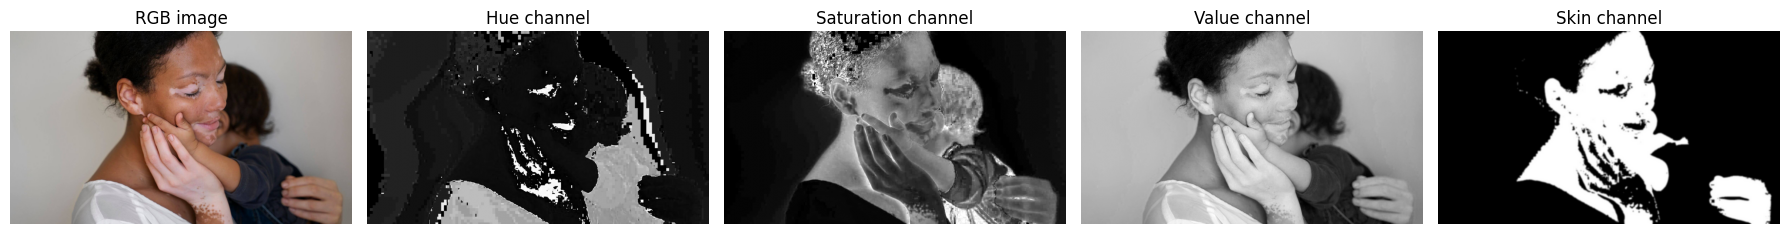

In [5]:
fig, (ax0, ax1, ax2, ax3, ax4) = plt.subplots(ncols=5, figsize=(18,12))

ax0.imshow(rgb_img)
ax0.set_title("RGB image")
ax0.axis('off')
ax1.imshow(hue_img, cmap='gray')
ax1.set_title("Hue channel")
ax1.axis('off')
ax2.imshow(sat_img, cmap='gray')
ax2.set_title("Saturation channel")
ax2.axis('off')
ax3.imshow(value_img, cmap='gray')
ax3.set_title("Value channel")
ax3.axis('off')

# Define o que é pele humana e o que não é
bin_img = (hue_img > 0/255) & (hue_img < 20/255) & (sat_img > 48/255) & \
   (sat_img < 255/255) & (value_img > 80/255) & (value_img < 255/255)

skin_img = np.zeros((width,height,3), dtype="uint8")
skin_img[:,:,0] = bin_img * 255 # for red
skin_img[:,:,1] = bin_img * 255 # for green
skin_img[:,:,2] = bin_img * 255 # for blue

skin_img = gaussian_filter(skin_img,sigma=3)
ax4.imshow(skin_img, cmap='gray')
ax4.set_title("Skin channel")
ax4.axis('off')
fig.tight_layout()

O "truque" aqui está em como o Python (e a biblioteca NumPy) trata valores booleanos (`True` e `False`) quando você tenta fazer matemática com eles.

Aqui está o que acontece passo a passo nessas linhas:

### 1\. Preparando a tela preta

```python
skin_img = np.zeros((width,height,3), dtype="uint8")
```

Primeiro, o código cria uma imagem nova (`skin_img`) do mesmo tamanho da original, mas totalmente preenchida com zeros.

  * Em imagens digitais, **0 é preto**.
  * Então, começamos com uma tela totalmente preta.

### 2\. A Mágica Matemática (`bin_img * 255`)

No Python, quando você multiplica um valor Booleano por um número, ele converte automaticamente:

  * **True vira 1**
  * **False vira 0**

Então a operação matemática que ocorre é:

  * Onde era "Pele" (`True`): $1 \times 255 = \mathbf{255}$ (Branco Brilhante)
  * Onde não era "Pele" (`False`): $0 \times 255 = \mathbf{0}$ (Preto Absoluto)

```text
Matriz Booleana (Exemplo do bin_img):
[[ True, False],
 [False,  True]]

Resultado da multiplicação por 255:
[[255,   0],
 [  0, 255]]
```

### 3\. Preenchendo os Canais (R, G, B)

```python
skin_img[:,:,0] = bin_img * 255 # Canal Vermelho
skin_img[:,:,1] = bin_img * 255 # Canal Verde
skin_img[:,:,2] = bin_img * 255 # Canal Azul
```

Como ele atribui o mesmo resultado (255 ou 0) para os três canais de cor (Vermelho, Verde e Azul):

  * Um pixel com (255, 255, 255) se torna **Branco**.
  * Um pixel com (0, 0, 0) permanece **Preto**.

É por isso que a imagem final é preto e branco. Ela é uma **máscara**: branca onde detectou pele e preta no resto.

### O Toque Final

Logo depois, tem essa linha:

```python
skin_img = gaussian_filter(skin_img, sigma=3)
```

Isso aplica um **desfoque (blur)** na máscara branca.

  * **Objetivo:** Suavizar as bordas duras da detecção de pele, fazendo a transição entre "pele" e "não-pele" parecer mais natural e menos pixelada. É por isso que na imagem final as "manchas" brancas parecem um pouco enevoadas nas bordas.